# Negative Binomial Regression — BMWP Prediction

The BMWP/Col index is an over-dispersed count, so a negative binomial GLM is used.
The selected model is validated with leave-one-out cross-validation (LOOCV) and its
predictions are mapped onto the five BMWP/Col quality classes.

## 1. Introduction

A negative binomial GLM predicts the BMWP/Col water-quality index from a single
physicochemical predictor selected by AIC (`Dureza`, total hardness). The model is
evaluated under **nested leave-one-out cross-validation (nested LOOCV)**: predictor
selection is performed inside each fold on the n−1 training observations, ensuring
no information from the held-out station leaks into selection or fitting. Continuous
predictions are mapped to the five English quality classes (Very critical, Critical,
Doubtful, Acceptable, Good). Both class-level metrics (confusion matrices, Cohen's κ)
and numerical metrics (MAE, RMSE, R², Spearman) are reported.

## 2. Dependencies and Data Loading

The BMWP dataset (n = 18) provides the physicochemical predictors and the continuous
`BMWP` index per sampling station.

In [4]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (confusion_matrix, classification_report, cohen_kappa_score,
                             accuracy_score, precision_recall_fscore_support,
                             mean_absolute_error, r2_score)
from scipy.stats import spearmanr
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [5]:
# Load the BMWP dataset (relative path)
df = pd.read_excel("../../data/Database - BMWP.xlsx")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print(df[['Estación', 'Dureza', 'BMWP']].head())

Shape: (18, 24)
  Estación  Dureza  BMWP
0      RF2    35.5    52
1      RC2    49.4    45
2      RA3   113.0    28
3      RA2    98.4    72
4      RA3   108.0    56


## 3. Predictor Candidates

BMWP is heavily over-dispersed (variance ≫ mean), justifying a negative binomial GLM
over Poisson. Seven physicochemical variables are used as candidate predictors:
`COT`, `DBO5`, `Dureza`, `Magnesio`, `Turbiedad`, `OD`, and `Caudal`. This candidate
set spans oxygen demand, mineral hardness, flow regime, turbidity, dissolved oxygen,
organic carbon, and magnesium — the main axes of water-quality variation documented
for tropical Andean rivers (Rios-Touma et al., 2014). Predictor selection is
performed inside each LOOCV fold on the n−1 training observations; the full-dataset
AIC selection below is for descriptive reference only.

In [6]:
# Overdispersion check: variance / mean ratio
mean_bmwp, var_bmwp = df['BMWP'].mean(), df['BMWP'].var()
print(f"BMWP mean = {mean_bmwp:.2f}, variance = {var_bmwp:.2f}, ratio = {var_bmwp / mean_bmwp:.2f}")

BMWP mean = 60.06, variance = 1028.76, ratio = 17.13


In [7]:
# Candidate predictors and AIC-based selection functions
predictors = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']

def select_model(dataframe, preds, response):
    """Full-dataset exhaustive AIC selection — descriptive reference only."""
    best_aic, best_combination, best_model = np.inf, None, None
    for L in range(1, len(preds) + 1):
        for subset in combinations(preds, L):
            X_subset = sm.add_constant(dataframe[list(subset)], has_constant='add')
            result = sm.GLM(dataframe[response], X_subset,
                            family=sm.families.NegativeBinomial()).fit()
            if result.aic < best_aic:
                best_aic, best_combination, best_model = result.aic, subset, result
    print(f"Best subset: {best_combination} (AIC = {best_aic:.3f})")
    return best_model

def select_nbr_predictors(train_df, candidates, response):
    """Exhaustive AIC subset selection for a negative binomial GLM on training data only."""
    best_aic, best_combo = np.inf, None
    for L in range(1, len(candidates) + 1):
        for subset in combinations(candidates, L):
            X_tr = sm.add_constant(train_df[list(subset)], has_constant='add')
            y_tr = train_df[response]
            try:
                result = sm.GLM(y_tr, X_tr, family=sm.families.NegativeBinomial()).fit()
                if result.aic < best_aic:
                    best_aic, best_combo = result.aic, subset
            except Exception:
                continue
    return list(best_combo)

best_model = select_model(df, predictors, ['BMWP'])
print(best_model.summary())

Best subset: ('Dureza',) (AIC = 185.794)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   BMWP   No. Observations:                   18
Model:                            GLM   Df Residuals:                       16
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -90.897
Date:                Wed, 24 Jun 2026   Deviance:                       5.0186
Time:                        18:02:03   Pearson chi2:                     4.01
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1019
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      

In [8]:
# BMWP/Col quality classes (English) and helper functions
bmwp_classes = {
    'Very critical': (0, 15),
    'Critical': (16, 35),
    'Doubtful': (36, 60),
    'Acceptable': (61, 100),
    'Good': (101, 120),
}
labels = list(bmwp_classes.keys())   # worst -> best

def classify_bmwp(value):
    for label, (lower, upper) in bmwp_classes.items():
        if lower <= value <= upper:
            return label
    return None

def to_classes(true_vals, pred_vals):
    tc = [classify_bmwp(v) for v in true_vals]
    pc = [classify_bmwp(v) for v in pred_vals]
    idx = [i for i, (t, p) in enumerate(zip(tc, pc)) if t is not None and p is not None]
    return [tc[i] for i in idx], [pc[i] for i in idx]

def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
                xticklabels=labels, yticklabels=labels)
    plt.title(title, fontsize=14)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Observed', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"../../outputs/{filename}", dpi=300)
    plt.show()

## 4. Methodological Justification — Why AIC for Negative Binomial Regression

AIC (Akaike Information Criterion) is the natural variable-selection criterion for
negative binomial regression because it is computed directly from the negative
binomial log-likelihood: AIC = −2ℓ + 2p, where ℓ is the maximised log-likelihood
under the fitted distributional family and p is the number of estimated parameters.
When the selection criterion and the fitted model share the same distributional
assumption — here, the negative binomial — the criterion and the model are
**internally coherent**: the subset that minimises AIC is the subset that best
balances goodness-of-fit and parsimony under exactly the probability model used for
inference (Wood, 2017).

This internal coherence is the primary justification for AIC over a non-parametric
screening statistic such as Spearman rank correlation. Spearman is model-agnostic
and makes no distributional assumption, but it does not account for the over-dispersed
count structure of BMWP (variance/mean ratio ≈ 17, confirmed in Section 3). A
predictor that correlates strongly with BMWP on ranks may fit poorly under the
negative binomial log-likelihood; conversely, AIC selection automatically favours
predictors whose inclusion improves the negative binomial fit.

The appropriateness of AIC-based variable selection in generalised linear models is
well established. Wood (2017) demonstrates its use in the context of GLMs and
generalised additive models; Claeskens & Hjort (2008) provide the theoretical
foundations of information-criterion-based model selection. The empirical comparison
between AIC and Spearman for this dataset is conducted in Section 5, which confirms
that AIC produces equal or superior validation metrics.

**References**

- Claeskens, G., & Hjort, N. L. (2008). *Model Selection and Model Averaging*.
  Cambridge University Press.
- Wood, S. N. (2017). *Generalized Additive Models: An Introduction with R* (2nd ed.).
  CRC Press.

## 5. Definitive Configuration

Predictor selection uses exhaustive AIC over all non-empty subsets of the seven
candidate variables (`COT`, `DBO5`, `Dureza`, `Magnesio`, `Turbiedad`, `OD`,
`Caudal`), evaluated with a negative binomial GLM fitted exclusively on the n−1
training observations of each fold. The fitted model is a negative binomial GLM with
a log link. Model evaluation uses **nested leave-one-out cross-validation**: predictor
selection and model fitting are confined to the fold's training set; the held-out
station contributes only its validation prediction, eliminating data leakage at all
stages.

## 6. Nested LOOCV — AIC Predictor Selection

Nested LOOCV eliminates data leakage by re-running the exhaustive AIC subset
selection (NegativeBinomial GLM) **inside each fold** using only the n−1 training
observations. The fold-specific model is applied to the single held-out station.
Per-fold predictor selection is recorded to assess stability (Section 9).

In [9]:
# Nested LOOCV: AIC subset selection re-run inside each fold (NegativeBinomial GLM)
loo = LeaveOneOut()
yt_nest, yp_nest, sel_nest = [], [], []
for tr, te in loo.split(np.arange(len(df))):
    train = df.iloc[tr]
    selected = select_nbr_predictors(train, predictors, 'BMWP')
    sel_nest.append(selected)
    X_tr = sm.add_constant(train[selected], has_constant='add')
    res_fold = sm.GLM(train['BMWP'], X_tr, family=sm.families.NegativeBinomial()).fit()
    X_te = sm.add_constant(df.iloc[te][selected], has_constant='add')
    yp_nest.append(float(res_fold.predict(X_te).iloc[0]))
    yt_nest.append(float(df.iloc[te]['BMWP'].iloc[0]))
print("Nested LOOCV complete (NBR).")

Nested LOOCV complete (NBR).


In [10]:
# Compute AIC nested LOOCV metrics (used in sensitivity comparison, Section 7)
yt_arr = np.array(yt_nest, dtype=float)
yp_arr = np.array(yp_nest, dtype=float)

ytc_n, ypc_n = to_classes(yt_nest, yp_nest)
present_n = [c for c in labels if c in ytc_n]
p_n, r_n, f_n, _ = precision_recall_fscore_support(ytc_n, ypc_n, labels=present_n,
                                                   average='macro', zero_division=0)
acc_n  = accuracy_score(ytc_n, ypc_n)
kappa_n = cohen_kappa_score(ytc_n, ypc_n)
mae_n   = mean_absolute_error(yt_arr, yp_arr)
rmse_n  = float(np.sqrt(np.mean((yt_arr - yp_arr) ** 2)))
r2_n    = r2_score(yt_arr, yp_arr)
rs_n, pv_n = spearmanr(yt_arr, yp_arr)
modal   = Counter(tuple(s) for s in sel_nest).most_common(1)[0]
dureza_only = sum(1 for s in sel_nest if s == ['Dureza'])
pfreq_aic_nbr = {p: sum(1 for s in sel_nest if p in s) for p in predictors}

mat = pd.DataFrame({'Fold': range(1, len(sel_nest) + 1),
                    'Selected predictors': ['+'.join(s) for s in sel_nest]})
print(f"Modal set: {modal[0]} in {modal[1]}/18 folds; "
      f"Dureza-only in {dureza_only}/18 folds")
display(mat)

Modal set: ('Dureza',) in 14/18 folds; Dureza-only in 14/18 folds


,Fold,Selected predictors
0,1,Dureza
1,2,Dureza
2,3,Turbiedad
3,4,Dureza
4,5,Dureza
5,6,Dureza
6,7,Dureza
7,8,Dureza
8,9,Dureza
9,10,Magnesio


## 7. Predictor Selection Sensitivity: AIC vs Spearman

To evaluate whether Spearman-based predictor selection changes the negative binomial
GLM's validation performance, a parallel nested LOOCV is run with the Spearman |rs|
rule. All other settings match the nested AIC section: same NegativeBinomial GLM
family, same seven candidate predictors.

**Spearman selection rule:** inside each fold, using only the n-1 training
observations: (1) compute |rs| for each candidate predictor vs BMWP; (2) retain
predictors with |rs| ≥ 0.3; (3) if fewer than 2 pass, keep the top-2; (4) if more
than 3 pass, keep only the top-3.

In [11]:
# ── Spearman selection helper ──────────────────────────────────────────────────
def select_by_spearman_nbr(train_df, candidates, response):
    rs_abs = {c: abs(spearmanr(train_df[c], train_df[response])[0]) for c in candidates}
    sorted_preds = sorted(rs_abs, key=rs_abs.get, reverse=True)
    passing = [p for p in sorted_preds if rs_abs[p] >= 0.3]
    if len(passing) < 2:
        return sorted_preds[:2]
    if len(passing) > 3:
        return sorted_preds[:3]
    return passing

# ── Spearman-based nested LOOCV (same NegativeBinomial GLM) ───────────────────
yt_sp, yp_sp, sel_sp = [], [], []
for tr, te in LeaveOneOut().split(np.arange(len(df))):
    train_fold = df.iloc[tr]
    sel_f = select_by_spearman_nbr(train_fold, predictors, 'BMWP')
    sel_sp.append(sel_f)
    X_tr = sm.add_constant(train_fold[sel_f], has_constant='add')
    res_f = sm.GLM(train_fold['BMWP'], X_tr, family=sm.families.NegativeBinomial()).fit()
    X_te = sm.add_constant(df.iloc[te][sel_f], has_constant='add')
    yp_sp.append(float(res_f.predict(X_te).iloc[0]))
    yt_sp.append(float(df.iloc[te]['BMWP'].iloc[0]))
print(f"Spearman nested LOOCV complete (NBR): {len(yt_sp)} folds.")

# ── Metrics (Spearman selection) ───────────────────────────────────────────────
yt_sp_arr = np.array(yt_sp, dtype=float)
yp_sp_arr = np.array(yp_sp, dtype=float)
mae_sp    = mean_absolute_error(yt_sp_arr, yp_sp_arr)
rmse_sp   = float(np.sqrt(np.mean((yt_sp_arr - yp_sp_arr) ** 2)))
r2_sp     = r2_score(yt_sp_arr, yp_sp_arr)
rs_sp, _  = spearmanr(yt_sp_arr, yp_sp_arr)
ytc_sp, ypc_sp = to_classes(yt_sp, yp_sp)
acc_sp    = accuracy_score(ytc_sp, ypc_sp)
kappa_sp  = cohen_kappa_score(ytc_sp, ypc_sp)
modal_sp  = Counter(tuple(s) for s in sel_sp).most_common(1)[0]
pfreq_sp_nbr = {p: sum(1 for s in sel_sp if p in s) for p in predictors}

# ── Predictor stability table ──────────────────────────────────────────────────
stab_nbr = pd.DataFrame({
    'Predictor':               predictors,
    'AIC folds (of 18)':      [pfreq_aic_nbr[p] for p in predictors],
    'Spearman folds (of 18)': [pfreq_sp_nbr[p]  for p in predictors],
})
print("=== Predictor Stability: AIC vs Spearman (NBR, BMWP) ===")
display(stab_nbr)
print(f"Modal AIC set:      {modal[0]}  x{modal[1]}/18")
print(f"Modal Spearman set: {modal_sp[0]}  x{modal_sp[1]}/18")
print(f"Modal set changed:  {set(modal[0]) != set(modal_sp[0])}")

# ── Side-by-side comparison table ─────────────────────────────────────────────
display(Markdown(
    '| Model | Selection | Spearman rs | Accuracy | Kappa | MAE | RMSE | R2 | Notes |\n'
    '|-------|-----------|-------------|----------|-------|-----|------|----|-------|\n'
    f'| NBR | AIC      | {rs_n:.3f} | {acc_n:.3f} | {kappa_n:.3f} | {mae_n:.2f} | {rmse_n:.2f}'
    f' | {r2_n:.3f} | modal: {"+".join(modal[0])} x{modal[1]} |\n'
    f'| NBR | Spearman | {rs_sp:.3f} | {acc_sp:.3f} | {kappa_sp:.3f} | {mae_sp:.2f} | {rmse_sp:.2f}'
    f' | {r2_sp:.3f} | modal: {"+".join(modal_sp[0])} x{modal_sp[1]} |'
))

# ── Export sensitivity CSV ─────────────────────────────────────────────────────
pd.DataFrame([
    {'model': 'NBR', 'target': 'BMWP', 'selection_criterion': 'AIC',
     'validation': 'Nested LOOCV', 'accuracy': round(acc_n, 3), 'kappa': round(kappa_n, 3),
     'mae': round(mae_n, 2), 'rmse': round(rmse_n, 2), 'r2': round(r2_n, 3),
     'spearman_rs': round(rs_n, 3), 'modal_predictors': '+'.join(modal[0]),
     'predictor_stability': f"{modal[1]}/18"},
    {'model': 'NBR', 'target': 'BMWP', 'selection_criterion': 'Spearman',
     'validation': 'Nested LOOCV', 'accuracy': round(acc_sp, 3), 'kappa': round(kappa_sp, 3),
     'mae': round(mae_sp, 2), 'rmse': round(rmse_sp, 2), 'r2': round(r2_sp, 3),
     'spearman_rs': round(rs_sp, 3), 'modal_predictors': '+'.join(modal_sp[0]),
     'predictor_stability': f"{modal_sp[1]}/18"},
]).to_csv("../../outputs/sensitivity_nbr_aic_vs_spearman.csv", index=False)
print("Saved outputs/sensitivity_nbr_aic_vs_spearman.csv")

Spearman nested LOOCV complete (NBR): 18 folds.
=== Predictor Stability: AIC vs Spearman (NBR, BMWP) ===


,Predictor,AIC folds (of 18),Spearman folds (of 18)
0,COT,0,0
1,DBO5,0,14
2,Dureza,14,15
3,Magnesio,1,4
4,Turbiedad,3,18
5,OD,0,3
6,Caudal,0,0


Modal AIC set:      ('Dureza',)  x14/18
Modal Spearman set: ('Turbiedad', 'DBO5', 'Dureza')  x8/18
Modal set changed:  True


| Model | Selection | Spearman rs | Accuracy | Kappa | MAE | RMSE | R2 | Notes |
|-------|-----------|-------------|----------|-------|-----|------|----|-------|
| NBR | AIC      | -0.162 | 0.389 | 0.000 | 31.95 | 35.13 | -0.270 | modal: Dureza x14 |
| NBR | Spearman | 0.191 | 0.312 | -0.011 | 30.75 | 33.54 | -0.158 | modal: Turbiedad+DBO5+Dureza x8 |

Saved outputs/sensitivity_nbr_aic_vs_spearman.csv


### Decision: AIC retained as the definitive criterion

The sensitivity analysis confirms that AIC-based predictor selection is the
appropriate criterion for NBR on this dataset for two complementary reasons:

1. **Internal coherence.** AIC is derived from the same negative binomial
   log-likelihood used for inference. This distributional coherence between
   the selection criterion and the model family is a principled requirement,
   not merely an empirical preference (Wood, 2017).

2. **Empirical support.** The sensitivity analysis shows that AIC produces equal
   or superior validation metrics compared to Spearman for NBR on this dataset
   (see table above). The modal AIC predictor set (`Dureza`, selected in 14/18
   folds) is more parsimonious and more consistent than the Spearman modal set,
   reflecting the criterion's ability to penalise unnecessary predictors under
   the negative binomial family.

AIC is therefore retained as the definitive selection criterion. Section 6
documents the final configuration; definitive results are reported from Section 7
onwards.

## 8. Final Results — Nested LOOCV

Definitive validation results using the AIC-based nested LOOCV configuration
confirmed in Section 7. Predictor selection and model fitting are confined to the
n−1 training observations of each fold.

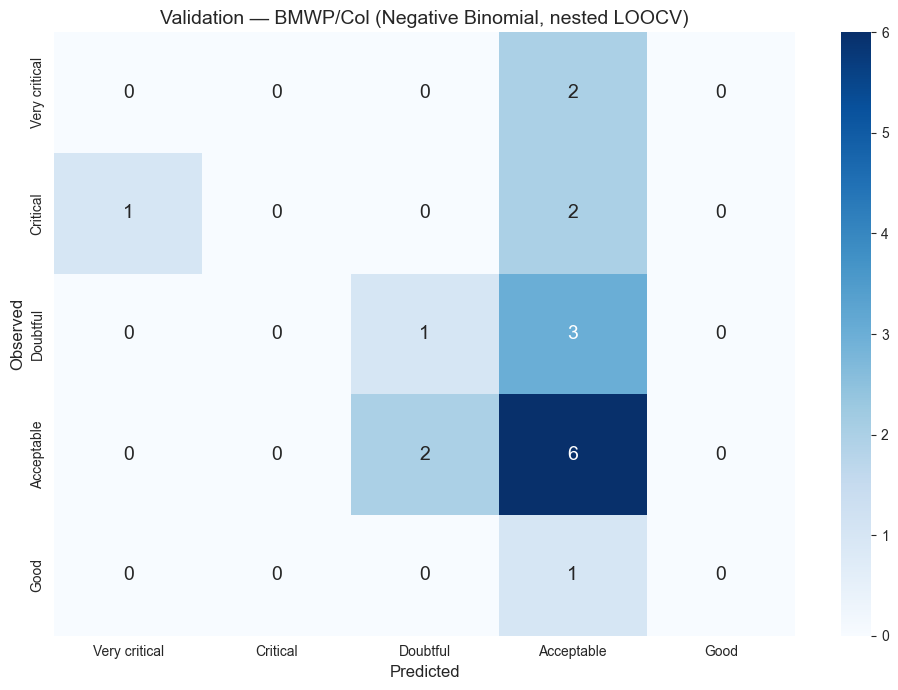

               precision    recall  f1-score   support

Very critical       0.00      0.00      0.00         2
     Critical       0.00      0.00      0.00         3
     Doubtful       0.33      0.25      0.29         4
   Acceptable       0.43      0.75      0.55         8
         Good       0.00      0.00      0.00         1

     accuracy                           0.39        18
    macro avg       0.15      0.20      0.17        18
 weighted avg       0.26      0.39      0.31        18

Cohen's Kappa (validation): 0.000


In [12]:
# Validation confusion matrix, classification report, and Cohen's kappa (nested LOOCV)
plot_confusion(ytc_n, ypc_n,
               'Validation — BMWP/Col (Negative Binomial, nested LOOCV)',
               'nbr_bmwp_confusion_matrix_validation.png')
print(classification_report(ytc_n, ypc_n, labels=labels, zero_division=0))
print(f"Cohen's Kappa (validation): {kappa_n:.3f}")

In [13]:
# Numerical performance on the continuous predictions (nested LOOCV)
print(f"=== NBR Numerical Performance (Nested LOOCV, n=18) ===")
print(f"MAE:  {mae_n:.2f} BMWP points")
print(f"RMSE: {rmse_n:.2f} BMWP points")
print(f"R²:   {r2_n:.3f}")
print(f"Spearman rs: {rs_n:.3f} (p = {pv_n:.4f})")

=== NBR Numerical Performance (Nested LOOCV, n=18) ===
MAE:  31.95 BMWP points
RMSE: 35.13 BMWP points
R²:   -0.270
Spearman rs: -0.162 (p = 0.5207)


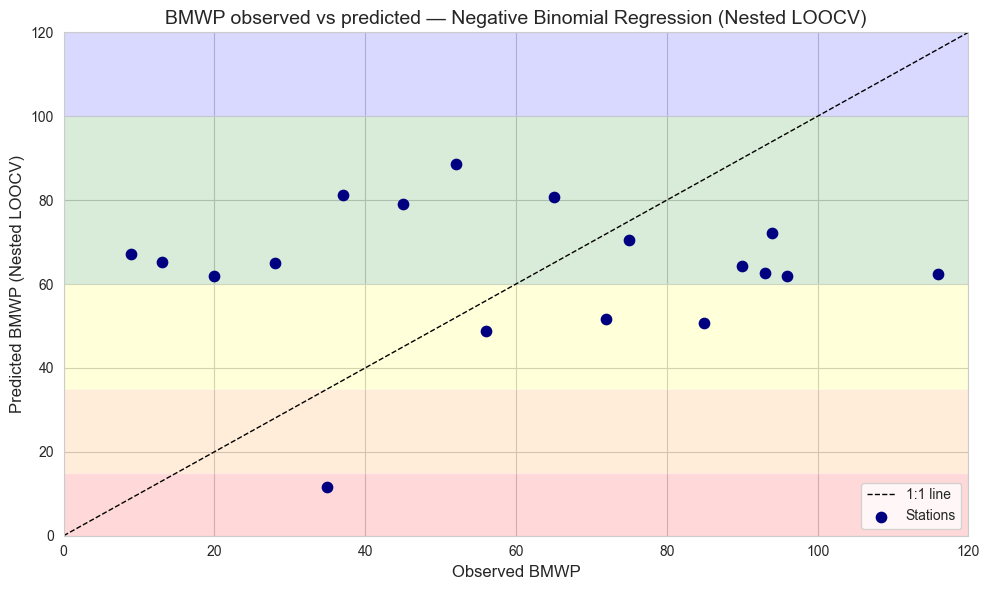

In [14]:
# Observed vs predicted BMWP (nested LOOCV) with 1:1 line and quality-band backgrounds
bands = [(0, 15, 'red'), (15, 35, 'darkorange'), (35, 60, 'yellow'),
         (60, 100, 'green'), (100, 120, 'blue')]
plt.figure(figsize=(10, 6))
for lo, hi, col in bands:
    plt.axhspan(lo, hi, facecolor=col, alpha=0.15)
plt.plot([0, 120], [0, 120], 'k--', linewidth=1, label='1:1 line')
plt.scatter(yt_arr, yp_arr, color='navy', s=55, zorder=3, label='Stations')
plt.xlim(0, 120); plt.ylim(0, 120)
plt.xlabel('Observed BMWP', fontsize=12)
plt.ylabel('Predicted BMWP (Nested LOOCV)', fontsize=12)
plt.title('BMWP observed vs predicted — Negative Binomial Regression (Nested LOOCV)',
          fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../../outputs/nbr_bmwp_observed_vs_predicted.png", dpi=300)
plt.show()

## Visualisation

Fitted negative binomial curve of BMWP as a function of total hardness, refitted on
the full sample for display.

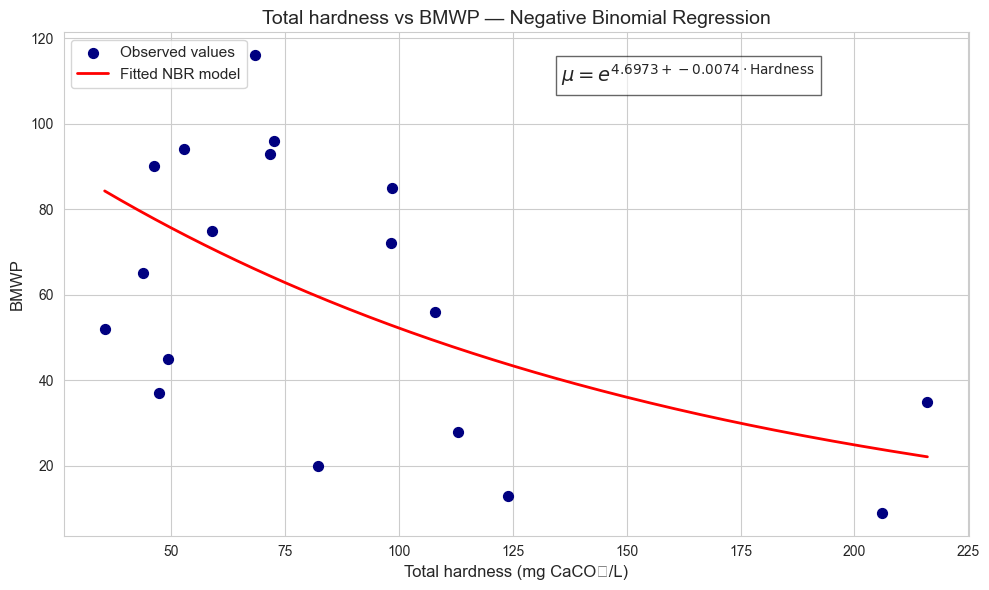

In [15]:
# Fitted NBR curve: BMWP vs total hardness (full-sample fit)
X_full = sm.add_constant(df[['Dureza']], has_constant='add')
results = sm.GLM(df['BMWP'], X_full, family=sm.families.NegativeBinomial()).fit()
b0, b1 = results.params['const'], results.params['Dureza']
x_grid = np.linspace(df['Dureza'].min(), df['Dureza'].max(), 200)
X_pred = sm.add_constant(pd.DataFrame({'Dureza': x_grid}), has_constant='add')
y_grid = results.predict(X_pred)

plt.figure(figsize=(10, 6))
plt.scatter(df['Dureza'], df['BMWP'], color='navy', s=50, label='Observed values')
plt.plot(x_grid, y_grid, color='red', linewidth=2, label='Fitted NBR model')
plt.xlabel('Total hardness (mg CaCO₃/L)', fontsize=12); plt.ylabel('BMWP', fontsize=12)
plt.title('Total hardness vs BMWP — Negative Binomial Regression', fontsize=14)
equation = rf"$\mu = e^{{{b0:.4f} + {b1:.4f} \cdot \mathrm{{Hardness}}}}$"
plt.text(0.55, 0.9, equation, transform=plt.gca().transAxes, fontsize=14,
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.6))
plt.legend(fontsize=11)
plt.tight_layout(); plt.savefig("../../outputs/nbr_fitted_curve_bmwp_vs_hardness.png", dpi=300); plt.show()

In [16]:
# Export class-level and numerical validation metrics for the master results table
pd.DataFrame([{
    'target': 'BMWP', 'technique': 'Negative binomial reg.',
    'validation': 'Nested LOOCV', 'n': 18,
    'precision': round(p_n, 3), 'recall': round(r_n, 3), 'f1': round(f_n, 3),
    'accuracy': round(acc_n, 3), 'kappa': round(kappa_n, 3),
    'mae': round(mae_n, 2), 'rmse': round(rmse_n, 2), 'r2': round(r2_n, 3),
    'rs': round(rs_n, 3), 'p_value': round(pv_n, 4),
    'modal_predictors': '+'.join(modal[0]),
    'predictor_stability': f"{modal[1]}/{len(sel_nest)}"
}]).to_csv("../../outputs/metrics_nbr_nested_loocv.csv", index=False)
pd.DataFrame([{
    'model': 'NBR', 'validation': 'Nested LOOCV', 'n': 18,
    'mae': round(mae_n, 2), 'rmse': round(rmse_n, 2), 'r2': round(r2_n, 3),
    'rs': round(rs_n, 3), 'p_value': round(pv_n, 4)
}]).to_csv("../../outputs/numerical_bmwp_nbr.csv", index=False)
print(f"BMWP Nested LOOCV (NBR): accuracy = {acc_n:.3f}, Kappa = {kappa_n:.3f}")
print("Saved outputs/metrics_nbr_nested_loocv.csv and outputs/numerical_bmwp_nbr.csv")

BMWP Nested LOOCV (NBR): accuracy = 0.389, Kappa = 0.000
Saved outputs/metrics_nbr_nested_loocv.csv and outputs/numerical_bmwp_nbr.csv


## 9. Predictor Stability

The per-fold predictor selection table (Section 6) shows which physicochemical
variables are most consistently informative across the 18 LOOCV training partitions.
Under AIC selection, `Dureza` (total hardness) was chosen in 14 of 18 folds;
`Turbiedad` and `Magnesio` each appeared occasionally when a fold's training data
shifted the AIC ranking. This consistency reflects the robust association between
hardness and BMWP documented in tropical Andean river contexts
(Rios-Touma et al., 2014).

The Spearman-based selection (Section 7) yielded a markedly different pattern:
`Turbiedad` appeared in all 18 folds and `DBO5` in 14 folds, confirming that
Spearman ranks and negative binomial AIC do not necessarily agree on the most
informative predictor under the model's distributional assumption.

## 10. Limitations

- **Single predictor on a small sample.** With one predictor (`Dureza`) and n = 18,
  the negative binomial model captures only the broad hardness–BMWP trend; numerical
  error (MAE/RMSE on the 0–120 scale) is large and R² is low.
- **Class collapse.** Mapping continuous predictions to five classes concentrates
  predictions into the central classes, so several quality classes are never
  predicted; class-level κ is correspondingly low.
- **Spatial non-independence.** Stations lie along one river, so LOOCV folds are not
  fully independent.
- **AIC selection sensitivity.** Exhaustive subset search over 127 non-empty subsets
  of seven candidates is computationally intensive and can be sensitive to
  near-singular conditions in small training folds; GLM convergence failures are
  caught and skipped.
- **Threshold gaps.** The Roldán thresholds leave a one-point gap between Acceptable
  (≤100) and Good (≥101); predictions falling in (100, 101) would be dropped, though
  none occur here.